## Evualuacion de los modelos

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, classification_report, roc_auc_score, roc_curve
from utils.model_utils import load_multiple_models,save_best_model
from constants import (
    predicted_dir, 
    X_val, X_val_scaled, 
    y_val, y_val_scaled,
    X_test, X_test_scaled
)
import os
from utils.model_utils import save_model
import time
import numpy as np

Cargamos los modelos

In [10]:
model_names = ["rf1", "rf2", "rf3", "rf4", "rf5", "rf6", "lr1", "lr2"]
models = load_multiple_models(model_names)

Procedemos a evaular los modelos con balanced_accuracy_score

In [11]:
X_dict = {
    # Original data models
    "rf1": X_val, 
    "rf2": X_val, 
    "rf3": X_val,
    "lr1": X_val,
    # Scaled data models  
    "rf4": X_val_scaled,
    "rf5": X_val_scaled, 
    "rf6": X_val_scaled,
    "lr2": X_val_scaled
}

In [12]:
y_dict = {
    # Original data models
    "rf1": y_val,
    "rf2": y_val,
    "rf3": y_val,
    "lr1": y_val,
    # Scaled data models
    "rf4": y_val_scaled,
    "rf5": y_val_scaled,
    "rf6": y_val_scaled,
    "lr2": y_val_scaled
}

Definimos la función para calcular el score compuesto calculando una puntuación compuesta que combina precisión y velocidad de convergencia de tal forma que conseguimos: 
    1. Equilibrio de Métricas:
       - Asigna 60% de peso a la precisión balanceada, ya que la calidad de predicción
         sigue siendo el factor más importante
       - Asigna 40% a la velocidad de convergencia, reconociendo la importancia de
         obtener un modelo eficiente en términos de entrenamiento
    
    2. Normalización de Convergencia:
       - Utiliza una función exponencial negativa (np.exp(-convergence_iterations/100))
         para transformar el número de iteraciones/árboles a una escala 0-1
       - Esta transformación asegura que:
         * Valores más bajos de iteraciones reciben puntuaciones más altas
         * La penalización es más fuerte para modelos que requieren muchas iteraciones
         * Se mantiene una escala comparable con la precisión balanceada
    
    3. Ventajas del Enfoque:
       - Permite identificar modelos que logran un buen balance entre precisión y eficiencia
       - Penaliza modelos que requieren recursos excesivos para converger
       - Facilita la comparación directa entre diferentes tipos de modelos (RF vs LR)

In [13]:
def calculate_composite_score(accuracy, convergence_iterations, accuracy_weight=0.6, convergence_weight=0.4):
    # Normalize convergence (lower is better, so we invert it)
    normalized_convergence = np.exp(-convergence_iterations/100)  # Scaled to handle different ranges
    return (accuracy_weight * accuracy) + (convergence_weight * normalized_convergence)

Evaluamos los modelos con el nuevo score compuesto

In [14]:
# Evaluate all models
results = {}
for name, model in models.items():
    # Get convergence information
    if name.startswith('rf'):
        # For Random Forest, check the number of trees needed
        convergence_metric = len(model.estimators_)
        convergence_type = "trees"
    else:  # Logistic Regression
        # For Logistic Regression, get number of iterations
        convergence_metric = model.n_iter_[0] if hasattr(model, 'n_iter_') else None
        convergence_type = "iterations"
    
    # Calculate metrics
    y_pred = model.predict(X_dict[name])
    bal_acc = balanced_accuracy_score(y_dict[name], y_pred)
    y_proba = model.predict_proba(X_dict[name])[:, 1] if hasattr(model, "predict_proba") else None
    auc = roc_auc_score(y_dict[name], y_proba) if y_proba is not None else None
    
    # Calculate composite score
    composite_score = calculate_composite_score(bal_acc, convergence_metric)
    
    print(f"\nEvaluating {name}:")
    print("-" * 50)
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Convergence ({convergence_type}): {convergence_metric}")
    print(f"Composite Score: {composite_score:.4f}")
    if auc is not None:
        print(f"AUC: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_dict[name], y_pred))
    
    results[name] = {
        "balanced_accuracy": bal_acc,
        "convergence_metric": convergence_metric,
        "convergence_type": convergence_type,
        "composite_score": composite_score,
        "auc": auc
    }


Evaluating rf1:
--------------------------------------------------
Balanced Accuracy: 0.8607
Convergence (trees): 100
Composite Score: 0.6636
AUC: 0.9769

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     38059
           1       0.94      0.72      0.82      1223

    accuracy                           0.99     39282
   macro avg       0.97      0.86      0.91     39282
weighted avg       0.99      0.99      0.99     39282


Evaluating rf2:
--------------------------------------------------
Balanced Accuracy: 0.8940
Convergence (trees): 200
Composite Score: 0.5905
AUC: 0.9555

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     38059
           1       0.62      0.80      0.70      1223

    accuracy                           0.98     39282
   macro avg       0.81      0.89      0.85     39282
weighted avg       0.98      0.98      0.98

Calculamos el mejor modelo


=== Best Model Based on Accuracy and Convergence ===
Best Model: rf4
Composite Score: 0.6638
Balanced Accuracy: 0.8611
Convergence (trees): 100


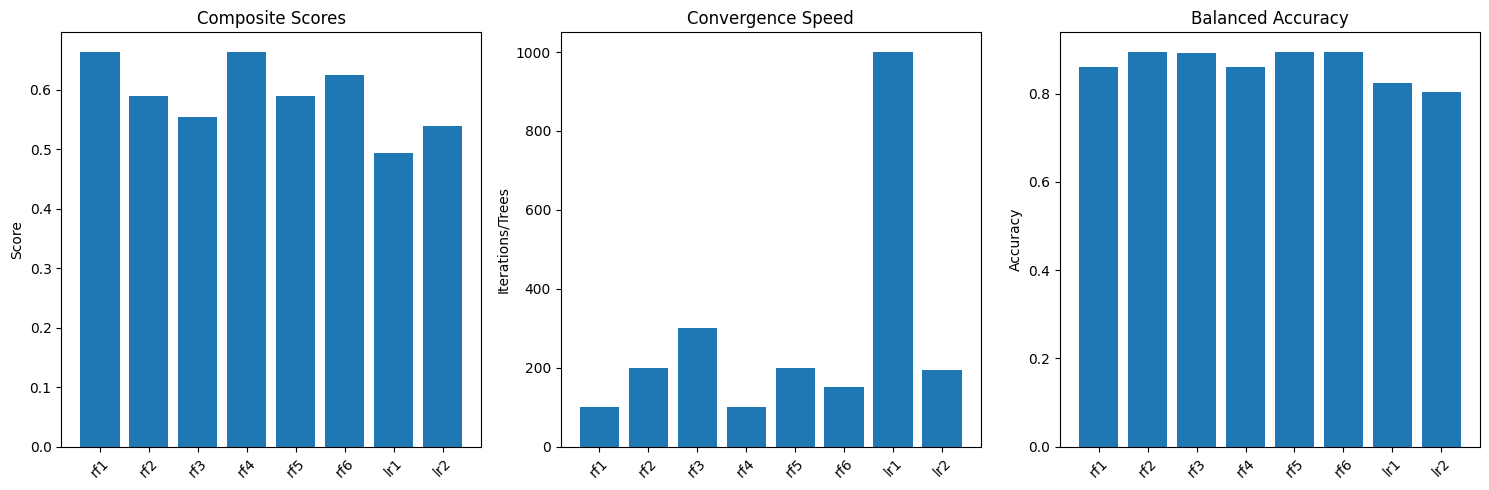

In [15]:
# Find best model using composite score
best_model_name = max(results.items(), key=lambda x: x[1]["composite_score"])[0]
best_result = results[best_model_name]

print("\n=== Best Model Based on Accuracy and Convergence ===")
print(f"Best Model: {best_model_name}")
print(f"Composite Score: {best_result['composite_score']:.4f}")
print(f"Balanced Accuracy: {best_result['balanced_accuracy']:.4f}")
print(f"Convergence ({best_result['convergence_type']}): {best_result['convergence_metric']}")

# Create visualization
plt.figure(figsize=(15, 5))

# Plot 1: Composite Scores
plt.subplot(1, 3, 1)
names = list(results.keys())
scores = [results[name]['composite_score'] for name in names]
plt.bar(names, scores)
plt.title('Composite Scores')
plt.xticks(rotation=45)
plt.ylabel('Score')

# Plot 2: Convergence Metrics
plt.subplot(1, 3, 2)
convergence = [results[name]['convergence_metric'] for name in names]
plt.bar(names, convergence)
plt.title('Convergence Speed')
plt.xticks(rotation=45)
plt.ylabel('Iterations/Trees')

# Plot 3: Balanced Accuracy
plt.subplot(1, 3, 3)
accuracies = [results[name]['balanced_accuracy'] for name in names]
plt.bar(names, accuracies)
plt.title('Balanced Accuracy')
plt.xticks(rotation=45)
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

Guardamos el mejor modelo para optimizarlo

In [16]:
save_best_model(models[best_model_name], best_model_name)

'./best_model\\rf4.joblib'